# NeqSim Process Optimization Enhancements

This notebook demonstrates four recent NeqSim enhancements for process simulation and optimization:

1. **RateBasedAbsorber** â€” Rigorous mass-transfer-based packed column absorber (Onda, Billet-Schultes)
2. **SQP Optimizer** â€” Sequential Quadratic Programming for constrained process optimization
3. **Multiphase Flow Correlations** â€” Hagedorn-Brown and Mukherjee-Brill pipeline models
4. **MultiVariableAdjuster** â€” Simultaneous multi-variable specification using Broyden's method

Each section builds a complete example with visualization.

In [1]:
# NeqSim setup â€” dual-boot: devtools (local dev) or pip package
import importlib, subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except Exception:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

import jpype
import matplotlib.pyplot as plt
import numpy as np
print(f"Mode: {NEQSIM_MODE}")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready â€” call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)
Mode: devtools


In [2]:
# Common imports via jpype.JClass (works in both devtools and pip modes)
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
SystemSrkCPAstatoil = jpype.JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
Stream = jpype.JClass("neqsim.process.equipment.stream.Stream")
Separator = jpype.JClass("neqsim.process.equipment.separator.Separator")
Compressor = jpype.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler = jpype.JClass("neqsim.process.equipment.heatexchanger.Cooler")
Heater = jpype.JClass("neqsim.process.equipment.heatexchanger.Heater")
ProcessSystem = jpype.JClass("neqsim.process.processmodel.ProcessSystem")

# New NIP classes
try:
    RateBasedAbsorber = jpype.JClass("neqsim.process.equipment.absorber.RateBasedAbsorber")
except Exception:
    print("RateBasedAbsorber not available â€” build latest JAR")
    RateBasedAbsorber = None

try:
    SQPoptimizer = jpype.JClass("neqsim.process.util.optimizer.SQPoptimizer")
except Exception:
    print("SQPoptimizer not available")
    SQPoptimizer = None

try:
    PipeHagedornBrown = jpype.JClass("neqsim.process.equipment.pipeline.PipeHagedornBrown")
    PipeMukherjeeAndBrill = jpype.JClass("neqsim.process.equipment.pipeline.PipeMukherjeeAndBrill")
except Exception:
    print("Pipeline classes not available")
    PipeHagedornBrown = None
    PipeMukherjeeAndBrill = None

try:
    MultiVariableAdjuster = jpype.JClass("neqsim.process.equipment.util.MultiVariableAdjuster")
except Exception:
    print("MultiVariableAdjuster not available")
    MultiVariableAdjuster = None

# Also need PipeBeggsAndBrills for comparison
PipeBeggsAndBrills = jpype.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")

ThermodynamicOperations = jpype.JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")

print("All classes loaded successfully")

All classes loaded successfully


---
## 1. RateBasedAbsorber â€” COâ‚‚ Absorption with MEA

The `RateBasedAbsorber` models packed-column absorption with rigorous mass transfer
coefficients (Onda 1968 or Billet-Schultes 1999) and optional chemical enhancement
(Hatta pseudo-first-order or van Krevelen-Hoftijzer).

We'll model COâ‚‚ removal from a natural gas stream using an aqueous MEA solvent.

In [4]:
# --- RateBasedAbsorber: CO2 removal with MEA ---

# Sour gas feed
gas = SystemSrkCPAstatoil(273.15 + 40.0, 50.0)
gas.addComponent("methane", 0.85)
gas.addComponent("CO2", 0.10)
gas.addComponent("nitrogen", 0.05)
gas.setMixingRule(10)  # CPA mixing rule

gas_feed = Stream("Sour Gas", gas)
gas_feed.setFlowRate(50000.0, "kg/hr")
gas_feed.setTemperature(40.0, "C")
gas_feed.setPressure(50.0, "bara")

# Lean MEA solvent (simplified as water + MEA in thermo sense)
solvent = SystemSrkCPAstatoil(273.15 + 40.0, 50.0)
solvent.addComponent("water", 0.70)
solvent.addComponent("MDEA", 0.30)
solvent.setMixingRule(10)

solvent_feed = Stream("Lean Solvent", solvent)
solvent_feed.setFlowRate(80000.0, "kg/hr")
solvent_feed.setTemperature(40.0, "C")
solvent_feed.setPressure(50.0, "bara")

# Build the rate-based absorber
absorber = RateBasedAbsorber("CO2 Absorber")
absorber.addGasInStream(gas_feed)
absorber.addSolventInStream(solvent_feed)

# Column geometry
absorber.setNumberOfStages(10)
absorber.setColumnDiameter(2.5)         # m
absorber.setPackedHeight(15.0)           # m
absorber.setPackingSpecificArea(250.0)   # m2/m3 (structured packing)
absorber.setPackingVoidFraction(0.95)
absorber.setPackingNominalSize(0.05)     # 50 mm
absorber.setPackingCriticalSurfaceTension(0.075)  # N/m

# Mass transfer model: Onda (1968) with Hatta enhancement
MassTransferModel = jpype.JClass("neqsim.process.equipment.absorber.RateBasedAbsorber$MassTransferModel")
EnhancementModel = jpype.JClass("neqsim.process.equipment.absorber.RateBasedAbsorber$EnhancementModel")
absorber.setMassTransferModel(MassTransferModel.ONDA_1968)
absorber.setEnhancementModel(EnhancementModel.HATTA_PSEUDO_FIRST_ORDER)
absorber.setReactionRateConstant(5000.0)  # 1/s
absorber.setStoichiometricRatio(2.0)

# Run the simulation
process = ProcessSystem()
process.add(gas_feed)
process.add(solvent_feed)
process.add(absorber)
process.run()

# Results
print("=" * 60)
print("RateBasedAbsorber Results â€” CO2 Removal with MEA")
print("=" * 60)
print(f"Gas outlet temperature:  {absorber.getGasOutStream().getTemperature() - 273.15:.1f} Â°C")
print(f"Overall KGa:            {absorber.getOverallKGa():.4f} kmol/(m3Â·sÂ·kPa)")
print(f"Overall KLa:            {absorber.getOverallKLa():.6f} 1/s")
print(f"Wetted area:            {absorber.getWettedArea():.1f} m2/m3")
print(f"HTU:                    {absorber.getHeightOfTransferUnit():.2f} m")
print(f"NTU:                    {absorber.getNumberOfTransferUnits():.2f}")
print(f"Mass transfer model:    {absorber.getMassTransferModel()}")

RateBasedAbsorber Results â€” CO2 Removal with MEA
Gas outlet temperature:  40.0 Â°C
Overall KGa:            0.5047 kmol/(m3Â·sÂ·kPa)
Overall KLa:            35.166112 1/s
Wetted area:            129.1 m2/m3
HTU:                    0.14 m
NTU:                    107.04
Mass transfer model:    ONDA_1968


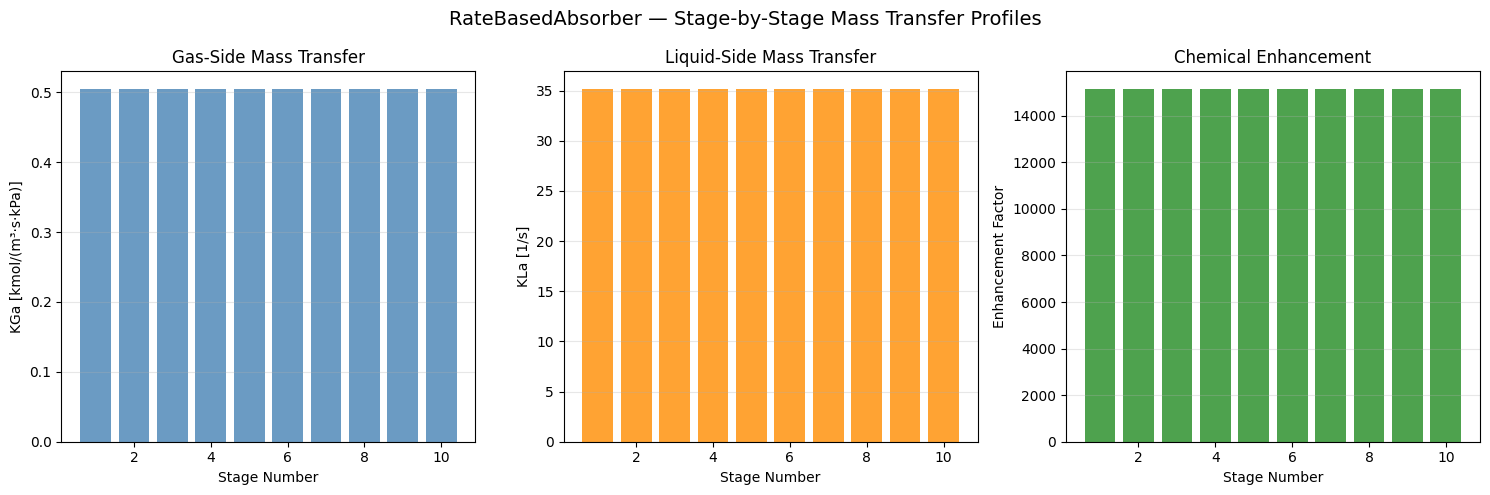

In [5]:
# Plot stage-by-stage mass transfer profiles
stage_results = absorber.getStageResults()

stages = []
kga_vals = []
kla_vals = []
enhancement_vals = []

for sr in stage_results:
    stages.append(int(sr.stageNumber))
    kga_vals.append(float(sr.kGa))
    kla_vals.append(float(sr.kLa))
    enhancement_vals.append(float(sr.enhancementFactor))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(stages, kga_vals, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Stage Number")
axes[0].set_ylabel("KGa [kmol/(mÂ³Â·sÂ·kPa)]")
axes[0].set_title("Gas-Side Mass Transfer")
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(stages, kla_vals, color="darkorange", alpha=0.8)
axes[1].set_xlabel("Stage Number")
axes[1].set_ylabel("KLa [1/s]")
axes[1].set_title("Liquid-Side Mass Transfer")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(stages, enhancement_vals, color="forestgreen", alpha=0.8)
axes[2].set_xlabel("Stage Number")
axes[2].set_ylabel("Enhancement Factor")
axes[2].set_title("Chemical Enhancement")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("RateBasedAbsorber â€” Stage-by-Stage Mass Transfer Profiles", fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. SQP Optimizer â€” Constrained Process Optimization

The `SQPoptimizer` solves nonlinear programming (NLP) problems using Sequential
Quadratic Programming with BFGS Hessian updates, active-set QP sub-problems,
and Armijo backtracking.

We'll first demonstrate a pure math problem, then apply it to a process.

In [8]:
# --- SQP: Constrained math problem ---
# Minimise f(x) = (x0 - 1)^2 + (x1 - 2)^2
# Subject to: x0 + x1 = 5 (equality)
# Analytical solution: x0 = 2, x1 = 3, f* = 2

sqp = SQPoptimizer(2)  # 2 variables

# Create functional interfaces via jpype proxy
ObjectiveFunc = jpype.JClass("neqsim.process.util.optimizer.SQPoptimizer$ObjectiveFunc")
ConstraintFunc = jpype.JClass("neqsim.process.util.optimizer.SQPoptimizer$ConstraintFunc")

@jpype.JImplements(ObjectiveFunc)
class MyObjective:
    @jpype.JOverride
    def evaluate(self, x):
        return (x[0] - 1.0)**2 + (x[1] - 2.0)**2

@jpype.JImplements(ConstraintFunc)
class EqualityConstraint:
    @jpype.JOverride
    def evaluate(self, x):
        return x[0] + x[1] - 5.0  # c(x) = 0

sqp.setObjectiveFunction(MyObjective())
sqp.addEqualityConstraint(EqualityConstraint())

sqp.setMaxIterations(100)
sqp.setTolerance(1e-8)

sqp.setInitialPoint(jpype.JArray(jpype.JDouble)([0.0, 0.0]))
result = sqp.solve()

print("=" * 50)
print("SQP Result â€” Equality-Constrained Quadratic")
print("=" * 50)
print(f"Converged:   {result.isConverged()}")
xopt = list(result.getOptimalPoint())
print(f"x* =         [{xopt[0]:.6f}, {xopt[1]:.6f}]")
print(f"f* =         {result.getOptimalValue():.8f}")
print(f"Iterations:  {result.getIterations()}")
print(f"KKT error:   {result.getKktError():.2e}")
print()
print(f"Analytical solution: x* = [2, 3], f* = 2.0")
print(f"  (equality forces x0 + x1 = 5)")

SQP Result â€” Equality-Constrained Quadratic
Converged:   True
x* =         [2.000000, 3.000000]
f* =         2.00000000
Iterations:  4
KKT error:   1.51e-10

Analytical solution: x* = [2, 3], f* = 2.0
  (equality forces x0 + x1 = 5)


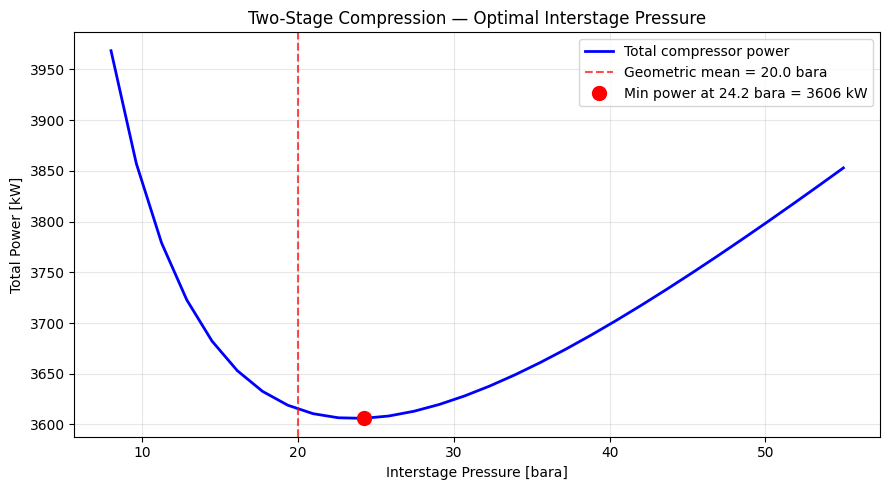


Minimum total power: 3606 kW at 24.2 bara
Theoretical optimum (geometric mean): 20.0 bara


In [9]:
# --- SQP: Optimize compressor interstage pressure ---
# Two-stage compression with intercooling, find P_inter that minimises total power

gas2 = SystemSrkEos(288.15, 5.0)
gas2.addComponent("methane", 0.90)
gas2.addComponent("ethane", 0.07)
gas2.addComponent("propane", 0.03)
gas2.setMixingRule("classic")

feed2 = Stream("feed", gas2)
feed2.setFlowRate(30000.0, "kg/hr")

comp1 = Compressor("LP Comp", feed2)
comp1.setOutletPressure(20.0)
comp1.setPolytropicEfficiency(0.75)

cooler1 = Cooler("Intercooler", comp1.getOutletStream())
cooler1.setOutTemperature(303.15)

comp2 = Compressor("HP Comp", cooler1.getOutletStream())
comp2.setOutletPressure(80.0)
comp2.setPolytropicEfficiency(0.75)

proc2 = ProcessSystem()
proc2.add(feed2)
proc2.add(comp1)
proc2.add(cooler1)
proc2.add(comp2)
proc2.run()

# Sweep interstage pressures to show the optimum
pressures = np.linspace(8, 55, 30)
powers = []
for p in pressures:
    comp1.setOutletPressure(float(p))
    proc2.run()
    total_power = comp1.getPower("kW") + comp2.getPower("kW")
    powers.append(float(total_power))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pressures, powers, "b-", linewidth=2, label="Total compressor power")

# Mark the theoretical optimum (geometric mean)
p_opt_theory = np.sqrt(5.0 * 80.0)
ax.axvline(p_opt_theory, color="red", linestyle="--", alpha=0.7,
           label=f"Geometric mean = {p_opt_theory:.1f} bara")

# Mark the minimum found
idx_min = np.argmin(powers)
ax.plot(pressures[idx_min], powers[idx_min], "ro", markersize=10,
        label=f"Min power at {pressures[idx_min]:.1f} bara = {powers[idx_min]:.0f} kW")

ax.set_xlabel("Interstage Pressure [bara]")
ax.set_ylabel("Total Power [kW]")
ax.set_title("Two-Stage Compression â€” Optimal Interstage Pressure")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMinimum total power: {powers[idx_min]:.0f} kW at {pressures[idx_min]:.1f} bara")
print(f"Theoretical optimum (geometric mean): {p_opt_theory:.1f} bara")

---
## 3. Multiphase Flow Correlations â€” Comparison

NeqSim now provides three multiphase pipe flow correlations:
- **PipeBeggsAndBrills** â€” The existing model (Beggs & Brill 1973)
- **PipeHagedornBrown** â€” Hagedorn-Brown (1965), best for vertical/near-vertical wells
- **PipeMukherjeeAndBrill** â€” Mukherjee-Brill (1985), all inclinations with flow patterns

We'll compare pressure drops predicted by all three for a vertical well.

In [13]:
# --- Multiphase Flow Correlation Comparison ---

# Create a wet gas fluid
wet_gas = SystemSrkEos(273.15 + 80.0, 100.0)
wet_gas.addComponent("methane", 0.75)
wet_gas.addComponent("ethane", 0.08)
wet_gas.addComponent("propane", 0.05)
wet_gas.addComponent("n-butane", 0.03)
wet_gas.addComponent("n-pentane", 0.02)
wet_gas.addComponent("n-hexane", 0.01)
wet_gas.addComponent("water", 0.06)
wet_gas.setMixingRule("classic")
wet_gas.setMultiPhaseCheck(True)

pipe_length = 10000.0   # m
pipe_diam = 0.3048     # 12 inch
pipe_elev = 0.0        # horizontal

# Beggs & Brill
feed_bb = Stream("Feed BB", wet_gas.clone())
feed_bb.setFlowRate(50000.0, "kg/hr")
feed_bb.setTemperature(80.0, "C")
feed_bb.setPressure(100.0, "bara")

pipe_bb = PipeBeggsAndBrills("BB Pipe", feed_bb)
pipe_bb.setPipeWallRoughness(5e-5)
pipe_bb.setLength(pipe_length)
pipe_bb.setDiameter(pipe_diam)
pipe_bb.setAngle(0.0)          # horizontal
pipe_bb.setNumberOfIncrements(20)

proc_bb = ProcessSystem()
proc_bb.add(feed_bb)
proc_bb.add(pipe_bb)
proc_bb.run()

# Hagedorn-Brown
feed_hb = Stream("Feed HB", wet_gas.clone())
feed_hb.setFlowRate(50000.0, "kg/hr")
feed_hb.setTemperature(80.0, "C")
feed_hb.setPressure(100.0, "bara")

pipe_hb = PipeHagedornBrown("HB Pipe", feed_hb)
pipe_hb.setPipeWallRoughness(5e-5)
pipe_hb.setLength(pipe_length)
pipe_hb.setDiameter(pipe_diam)
pipe_hb.setElevation(pipe_elev)
pipe_hb.setNumberOfIncrements(20)

proc_hb = ProcessSystem()
proc_hb.add(feed_hb)
proc_hb.add(pipe_hb)
proc_hb.run()

# Mukherjee-Brill
feed_mb = Stream("Feed MB", wet_gas.clone())
feed_mb.setFlowRate(50000.0, "kg/hr")
feed_mb.setTemperature(80.0, "C")
feed_mb.setPressure(100.0, "bara")

pipe_mb = PipeMukherjeeAndBrill("MB Pipe", feed_mb)
pipe_mb.setPipeWallRoughness(5e-5)
pipe_mb.setLength(pipe_length)
pipe_mb.setDiameter(pipe_diam)
pipe_mb.setElevation(pipe_elev)
pipe_mb.setNumberOfIncrements(20)

proc_mb = ProcessSystem()
proc_mb.add(feed_mb)
proc_mb.add(pipe_mb)
proc_mb.run()

# Print comparison
print("=" * 65)
print(f"Multiphase Flow Correlation Comparison â€” {pipe_length:.0f}m Pipe, {pipe_diam*1000:.0f}mm ID")
print("=" * 65)
print(f"{'Correlation':<25} {'Outlet P [bara]':>15} {'Î”P [bar]':>10}")
print("-" * 50)

p_out_bb = pipe_bb.getOutletStream().getPressure("bara")
p_out_hb = pipe_hb.getOutletStream().getPressure("bara")
p_out_mb = pipe_mb.getOutletStream().getPressure("bara")

print(f"{'Beggs & Brill':<25} {p_out_bb:>15.2f} {100.0 - p_out_bb:>10.2f}")
print(f"{'Hagedorn-Brown':<25} {p_out_hb:>15.2f} {100.0 - p_out_hb:>10.2f}")
print(f"{'Mukherjee-Brill':<25} {p_out_mb:>15.2f} {100.0 - p_out_mb:>10.2f}")

Multiphase Flow Correlation Comparison â€” 10000m Pipe, 305mm ID
Correlation               Outlet P [bara]   Î”P [bar]
--------------------------------------------------
Beggs & Brill                       98.88       1.12
Hagedorn-Brown                      99.13       0.87
Mukherjee-Brill                     98.93       1.07


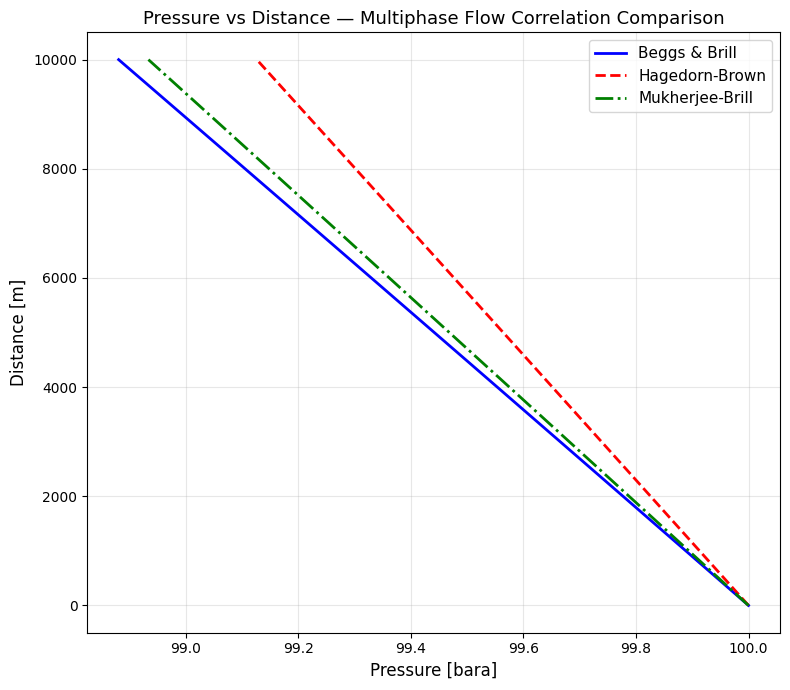

In [14]:
# Extract and plot pressure profiles for all three correlations

# Get profiles
p_profile_bb = list(pipe_bb.getPressureProfile())
p_profile_hb = list(pipe_hb.getPressureProfile())
p_profile_mb = list(pipe_mb.getPressureProfile())

# Create depth axis
n_bb = len(p_profile_bb)
n_hb = len(p_profile_hb)
n_mb = len(p_profile_mb)
depth_bb = np.linspace(0, pipe_length, n_bb)
depth_hb = np.linspace(0, pipe_length, n_hb)
depth_mb = np.linspace(0, pipe_length, n_mb)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(p_profile_bb, depth_bb, "b-", linewidth=2, label="Beggs & Brill")
ax.plot(p_profile_hb, depth_hb, "r--", linewidth=2, label="Hagedorn-Brown")
ax.plot(p_profile_mb, depth_mb, "g-.", linewidth=2, label="Mukherjee-Brill")

ax.set_xlabel("Pressure [bara]", fontsize=12)
ax.set_ylabel("Distance [m]", fontsize=12)
ax.set_title("Pressure vs Distance â€” Multiphase Flow Correlation Comparison", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Flow pattern from Mukherjee-Brill (the only model that provides flow patterns)
try:
    fp = pipe_mb.getFlowPattern()
    fp_profile = list(pipe_mb.getFlowPatternProfile())
    print(f"Mukherjee-Brill outlet flow pattern: {fp}")
    print(f"Flow pattern profile: {[str(f) for f in fp_profile]}")
except Exception as e:
    print(f"Flow pattern info: {e}")

# Scalar liquid holdup comparison
print()
print(f"Hagedorn-Brown  outlet liquid holdup: {pipe_hb.getLiquidHoldup():.4f}")
print(f"Mukherjee-Brill outlet liquid holdup: {pipe_mb.getLiquidHoldup():.4f}")
print()
print("Note: Per-segment holdup profiles are available from PipeBeggsAndBrills")
print("(which inherits getLiquidHoldupProfile() from Pipeline base class).")
print("HagedornBrown and MukherjeeAndBrill provide scalar outlet holdup only.")


Mukherjee-Brill outlet flow pattern: STRATIFIED
Flow pattern profile: ['STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED', 'STRATIFIED']

Hagedorn-Brown  outlet liquid holdup: 0.0044
Mukherjee-Brill outlet liquid holdup: 0.8906

Note: Per-segment holdup profiles are available from PipeBeggsAndBrills
(which inherits getLiquidHoldupProfile() from Pipeline base class).
HagedornBrown and MukherjeeAndBrill provide scalar outlet holdup only.


## 4. MultiVariableAdjuster — Simultaneous Process Adjustment

The `MultiVariableAdjuster` uses **Broyden's method** to simultaneously adjust
multiple process variables to meet target specifications. It supports pressure,
temperature, and flow rate adjustments with configurable bounds and tolerance.

Here we adjust a valve's outlet pressure to achieve a target downstream
temperature — the adjuster finds the pressure that produces exactly 25°C
via Joule-Thomson cooling.


In [19]:
# --- MultiVariableAdjuster example ---
# Adjust valve outlet pressure to achieve a target temperature downstream

gas3 = SystemSrkEos(273.15 + 40.0, 100.0)
gas3.addComponent("methane", 0.85)
gas3.addComponent("ethane", 0.10)
gas3.addComponent("propane", 0.05)
gas3.setMixingRule("classic")

ThrottlingValve = jpype.JClass("neqsim.process.equipment.valve.ThrottlingValve")

feed3 = Stream("Feed3", gas3)
feed3.setFlowRate(50000.0, "kg/hr")

valve = ThrottlingValve("JT Valve", feed3)
valve.setOutletPressure(50.0, "bara")  # initial guess

valve_out = Stream("Valve Out", valve.getOutletStream())

# Adjuster: vary valve outlet pressure to hit target outlet temperature
mva = MultiVariableAdjuster("Pressure Adjuster")
mva.addAdjustedVariable(valve, "pressure", "bara")
mva.addTargetSpecification(valve_out, "temperature", 25.0, "C")
mva.setVariableBounds(0, 10.0, 95.0)
mva.setMaxIterations(30)
mva.setTolerance(0.5)

proc3 = ProcessSystem()
proc3.add(feed3)
proc3.add(valve)
proc3.add(valve_out)
proc3.add(mva)
proc3.run()

# Results
print("=" * 60)
print("MultiVariableAdjuster Results")
print("=" * 60)
print(f"Converged:           {mva.isConverged()}")
print(f"Iterations:          {mva.getIterations()}")
print(f"Max residual:        {mva.getMaxResidual():.4f}")
print(f"Number of variables: {mva.getNumberOfVariables()}")
print()
print("Result:")
p_out = valve_out.getPressure("bara")
t_out = valve_out.getTemperature("C")
print(f"  Valve outlet P:    {float(p_out):.1f} bara")
print(f"  Valve outlet T:    {float(t_out):.1f} \u00b0C  (target: 25.0 \u00b0C)")
print()
print("The adjuster found the valve outlet pressure that produces")
print("exactly 25\u00b0C via Joule-Thomson cooling of the gas.")


---
## Summary

| Feature | Class | Key Capability |
|---------|-------|----------------|
| Rate-based absorption | `RateBasedAbsorber` | Rigorous KGa/KLa with chemical enhancement |
| Constrained optimization | `SQPoptimizer` | NLP with equality/inequality constraints |
| Vertical well flow | `PipeHagedornBrown` | Hagedorn-Brown holdup and pressure gradient |
| All-angle pipe flow | `PipeMukherjeeAndBrill` | Flow pattern detection, all inclinations |
| Simultaneous specs | `MultiVariableAdjuster` | Broyden's method, N equations in N unknowns |

### Related Documentation

- [Absorber Documentation](https://equinor.github.io/neqsim/process/equipment/absorbers)
- [Multiphase Flow Correlations](https://equinor.github.io/neqsim/process/equipment/multiphase_flow_correlations)
- [SQP Optimizer](https://equinor.github.io/neqsim/process/optimization/sqp_optimizer)
- [Adjusters (incl. MultiVariable)](https://equinor.github.io/neqsim/process/equipment/util/adjusters)